# Tarea 1 - Inteligencia Artificial
## Parte 1: Redes Bayesianas

**Estudiante(s):** Vicente Díaz, Fernanda Valencia

**Fecha:** Abril 2026

---

## Dataset: Women's E-Commerce Clothing Reviews

Este dataset contiene más de 23.000 reseñas de ropa femenina publicadas en una plataforma de comercio electrónico. Cada fila corresponde a una reseña e incluye información sobre el artículo, la edad de quien escribe, la calificación otorgada, si el producto es recomendado o no, la cantidad de votos positivos recibidos y la categoría a la que pertenece el artículo.

## Introducción

El objetivo principal de este trabajo es aplicar el modelo de **Redes Bayesianas** a un conjunto de datos real de e-commerce (`Womens Clothing E-Commerce Reviews.csv`), con el fin de descubrir e inferir las relaciones probables entre la recomendación de una prenda, el departamento al que pertenece, su calificación (rating) y el feedback positivo recibido.

**Metodología y funcionamiento general de los scripts:** 
A lo largo de este *notebook*, la ejecución sigue un flujo lógico descrito a continuación:
1. **Carga y Preprocesamiento**: Se extraen los datos mediante `pandas`, eliminando texto irrelevante, discretizando valores continuos y variables sin importancia predictiva, dejando variables categóricas listas para la red bayesiana.
2. **Aprendizaje de Estructura**: Se emplean dos metodologías de la librería `pgmpy` para hallar la estructura del grafo: *ExhaustiveSearch* (escaneo de todas las combinaciones posibles) y *HillClimbSearch* (búsqueda heurística iterativa). Internamente, los scripts prueban distintos grafos uniendo nodos hasta seleccionar la estructura de red de mayor `score`.
3. **Parámetros e Inferencias**: Una vez encontrada la estructura definitiva de la red, los scripts calculan las tablas de probabilidad condicional (CPDs) basándose en las frecuencias (Maximum Likelihood). Usando la clase `VariableElimination`, consultamos estas tablas subyacentes para inferir cuán probable es un evento dada nueva evidencia.
4. **Generación Sintética**: Finalmente, mediante funciones personalizadas usando estimadores bayesianos de muestreo (`BayesianModelSampling`), los scripts simulan nuevos datos respetando las probabilidades ya descubiertas para validar y comparar estadísticamente el modelo frente a volúmenes más grandes (10%, 20%, 40% adicional).


In [ ]:
!pip install pgmpy pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import ExhaustiveSearch, HillClimbSearch
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination
from pgmpy.sampling import BayesianModelSampling
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Carga y Exploración del Dataset [Rúbrica 1.1]

Se carga el dataset directamente desde el archivo CSV y se realiza una revisión inicial de su estructura, tipos de datos y estadísticas descriptivas básicas.

In [ ]:
df = pd.read_csv(r'C:\Users\PC\OneDrive\Documentos\Universidad\Semestre 8\Inteligencia Artificial\dataser_review\Womens Clothing E-Commerce Reviews.csv', index_col=0)

print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: (23486, 10)

Primeras filas:


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
print("Información del dataset:")
df.info()
print("\n" + "="*50)
print("Estadísticas descriptivas:")
df.describe()

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended IND          23486 non-null  int64
 6   Positive Feedback Count  23486 non-null  int64
 7   Division Name            23472 non-null  str  
 8   Department Name          23472 non-null  str  
 9   Class Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB

Estadísticas descriptivas:


,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal de filas: {len(df)}")
print(f"Total de columnas: {df.shape[1]}")

Valores nulos por columna:
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Total de filas: 23486
Total de columnas: 10


## 2. Preprocesamiento de Datos

Para poder construir la Red Bayesiana es necesario trabajar exclusivamente con variables categóricas. Las variables numéricas continuas deben discretizarse y los valores faltantes deben eliminarse o imputarse.

De las 10 columnas disponibles se seleccionaron **7** que resultan relevantes para modelar las relaciones de interés:

- **Age** → discretizada en grupos etarios: 18-25, 26-35, 36-45, 46-55, 56+
- **Rating** → se conserva como variable ordinal (1 a 5)
- **Recommended IND** → binaria (Sí / No)
- **Positive Feedback Count** → discretizada en niveles: None, Low, Medium, High
- **Division Name** → variable categórica original
- **Department Name** → variable categórica original
- **Class Name** → variable categórica original

Se descartan `Title` y `Review Text` por ser texto libre, y `Clothing ID` por ser un identificador sin valor predictivo.
Las filas con valores nulos en cualquiera de las columnas seleccionadas se eliminan, lo que resulta en un dataset limpio de 23.472 registros.

In [ ]:
columnas_utiles = ['Age', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

df_bn = df[columnas_utiles].copy()

df_bn = df_bn.dropna()

print(f"Dataset después de limpieza: {df_bn.shape}")
print(f"\nValores nulos restantes: {df_bn.isnull().sum().sum()}")

Dataset después de limpieza: (23472, 7)

Valores nulos restantes: 0


In [ ]:
df_bn['Age_Group'] = pd.cut(df_bn['Age'],  bins=[0, 25, 35, 45, 55, 100],  labels=['18-25', '26-35', '36-45', '46-55', '56+'])

df_bn['Feedback_Level'] = pd.cut(df_bn['Positive Feedback Count'],   bins=[-1, 0, 5, 15, 1000],   labels=['None', 'Low', 'Medium', 'High'])

df_bn['Rating_Cat'] = df_bn['Rating'].astype(str)

df_bn['Recommended'] = df_bn['Recommended IND'].map({0: 'No', 1: 'Yes'})

df_discreto = df_bn[['Age_Group', 'Rating_Cat', 'Recommended', 'Feedback_Level',  'Division Name', 'Department Name', 'Class Name']].copy()

df_discreto.columns = ['Age_Group', 'Rating', 'Recommended', 'Feedback',    'Division', 'Department', 'Class']

df_discreto = df_discreto.astype(str)

df_discreto = df_discreto.replace('nan', np.nan).dropna()

print(f"Dataset discretizado: {df_discreto.shape}")
print(f"\nPrimeras filas:")
df_discreto.head()

Dataset discretizado: (23472, 7)

Primeras filas:


,Age_Group,Rating,Recommended,Feedback,Division,Department,Class
0,26-35,4,Yes,None,Initmates,Intimate,Intimates
1,26-35,5,Yes,Low,General,Dresses,Dresses
2,56+,3,No,None,General,Dresses,Dresses
3,46-55,5,Yes,None,General Petite,Bottoms,Pants
4,46-55,5,Yes,Medium,General,Tops,Blouses


In [ ]:
print("Valores únicos por columna:")
for col in df_discreto.columns:
    print(f"\n{col}: {df_discreto[col].nunique()} valores únicos")
    print(f"  Valores: {df_discreto[col].unique()[:10]}")

Valores únicos por columna:

Age_Group: 5 valores únicos
  Valores: <StringArray>
['26-35', '56+', '46-55', '36-45', '18-25']
Length: 5, dtype: str

Rating: 5 valores únicos
  Valores: <StringArray>
['4', '5', '3', '2', '1']
Length: 5, dtype: str

Recommended: 2 valores únicos
  Valores: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Feedback: 4 valores únicos
  Valores: <StringArray>
['None', 'Low', 'Medium', 'High']
Length: 4, dtype: str

Division: 3 valores únicos
  Valores: <StringArray>
['Initmates', 'General', 'General Petite']
Length: 3, dtype: str

Department: 6 valores únicos
  Valores: <StringArray>
['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend']
Length: 6, dtype: str

Class: 20 valores únicos
  Valores: <StringArray>
[ 'Intimates',    'Dresses',      'Pants',    'Blouses',      'Knits',
  'Outerwear',     'Lounge',   'Sweaters',     'Skirts', 'Fine gauge']
Length: 10, dtype: str


## 3. Aprendizaje de Estructura: Búsqueda Exhaustiva (ExhaustiveSearch) [Rúbrica 1.2]

### ¿Qué hace este método? [Rúbrica 1.4]

**ExhaustiveSearch** recorre *todos* los posibles grafos acíclicos dirigidos (DAGs) formados por las variables del dataset y selecciona aquel que maximiza una métrica de puntuación, habitualmente BIC o K2.

El procedimiento es el siguiente:
1. Se enumeran todos los DAGs posibles para el conjunto de variables dado.
2. Para cada estructura se calcula el score (en este caso, el predeterminado de pgmpy).
3. Se devuelve la estructura con la puntuación más alta.

**Ventajas:**
- Garantiza encontrar la estructura óptima según el criterio elegido.
- No depende de ninguna inicialización aleatoria.

**Desventajas:**
- La cantidad de DAGs posibles crece de forma superexponencial con el número de variables. Para *n* = 5 ya hay miles de grafos candidatos; para *n* = 10 el número se vuelve completamente inmanejable.
- El costo computacional hace que sea impráctica en datasets con más de 5 o 6 variables.

### Justificación de la reducción a 5 variables

Dado que ExhaustiveSearch tiene complejidad superexponencial, se optó por trabajar con un subconjunto de **5 variables**: Rating, Recommended, Feedback, Division y Department. Se descartaron `Age_Group` y `Class` porque, aunque aportan información, la relación entre calificación, recomendación y nivel de feedback ya captura el núcleo del fenómeno de interés. Incluir más variables habría hecho el proceso prohibitivamente lento sin un aporte proporcional en la calidad del modelo.

In [ ]:
columnas_exhaustive = ['Rating', 'Recommended', 'Feedback', 'Division', 'Department']
df_exhaustive = df_discreto[columnas_exhaustive].copy()

print(f"Dataset para ExhaustiveSearch: {df_exhaustive.shape}")
print(f"Variables seleccionadas: {list(df_exhaustive.columns)}")

Dataset para ExhaustiveSearch: (23472, 5)
Variables seleccionadas: ['Rating', 'Recommended', 'Feedback', 'Division', 'Department']


In [ ]:
import time

print("Ejecutando ExhaustiveSearch...")
print("Nota: Este proceso puede tomar varios minutos debido a la naturaleza exhaustiva del algoritmo.\n")

inicio = time.time()
df_exhaustive = df_exhaustive.astype('category')
#scoring_method = BicScore(df_exhaustive)
exhaustive_search = ExhaustiveSearch(df_exhaustive)
# Encontrar la mejor estructura
best_model_exhaustive = exhaustive_search.estimate()

fin = time.time()

print(f"ExhaustiveSearch completado en {fin-inicio:.2f} segundos")
print(f"\nEstructura encontrada (aristas):")
print(best_model_exhaustive.edges())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C'}


Ejecutando ExhaustiveSearch...
Nota: Este proceso puede tomar varios minutos debido a la naturaleza exhaustiva del algoritmo.

✓ ExhaustiveSearch completado en 25.19 segundos

Estructura encontrada (aristas):
[('Department', 'Division'), ('Department', 'Feedback'), ('Feedback', 'Recommended'), ('Recommended', 'Rating')]


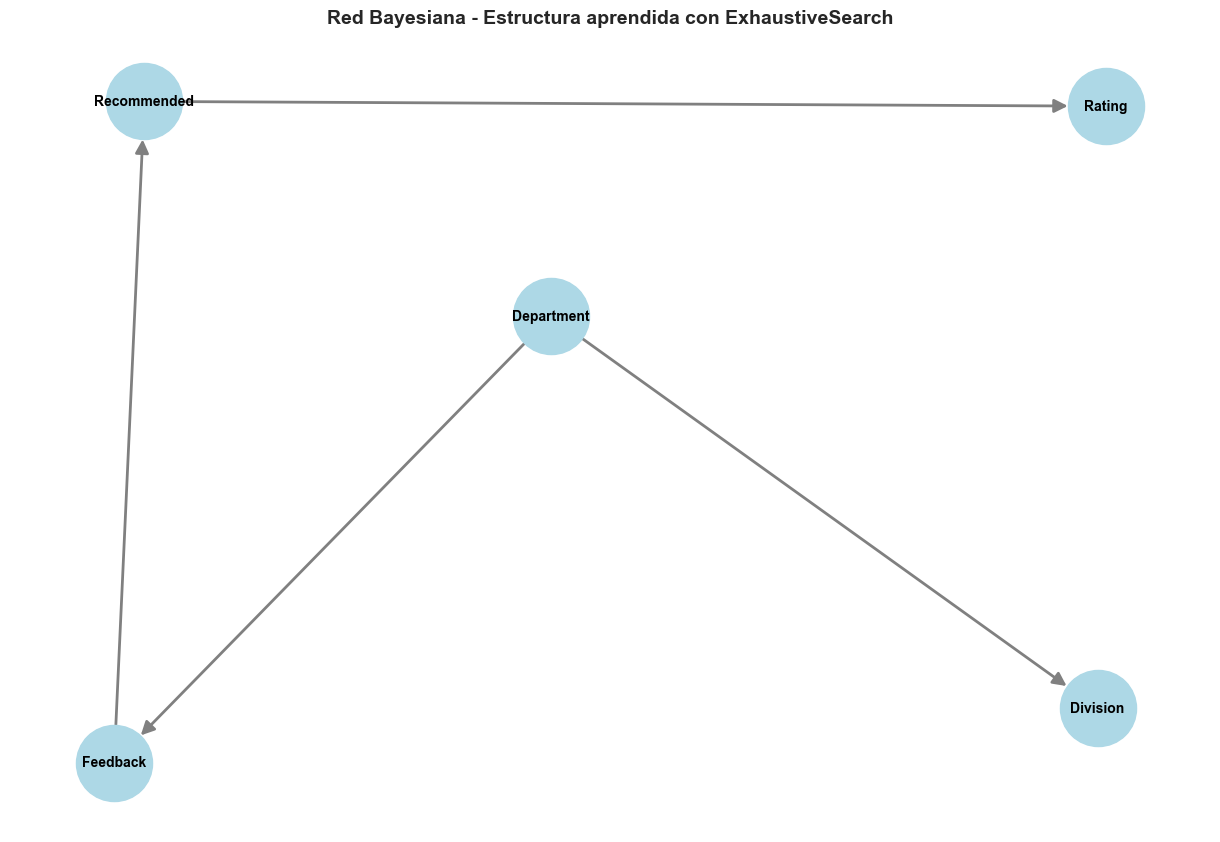


Número de aristas: 4
Nodos: ['Department', 'Division', 'Feedback', 'Rating', 'Recommended']


In [ ]:
import networkx as nx

plt.figure(figsize=(12, 8))
G_exhaustive = nx.DiGraph(best_model_exhaustive.edges())
pos = nx.spring_layout(G_exhaustive, k=2, iterations=50, seed=42)

nx.draw(G_exhaustive, pos, 
        with_labels=True, 
        node_color='lightblue', 
        node_size=3000, 
        font_size=10, 
        font_weight='bold',
        arrows=True,
        arrowsize=20,
        edge_color='gray',
        width=2)

plt.title("Red Bayesiana - Estructura aprendida con ExhaustiveSearch", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nNúmero de aristas: {len(best_model_exhaustive.edges())}")
print(f"Nodos: {list(best_model_exhaustive.nodes())}")

### Deducción de la Estructura Encontrada (ExhaustiveSearch)
La estructura resultante de la búsqueda exhaustiva refleja un ordenamiento probabilístico intuitivo. El algoritmo encontró de manera natural que la retroalimentación (`Feedback`) y si la prenda fue recomendada (`Recommended`) actúan como nodos intermedios/padres directos determinantes en la calificación final otorgada (`Rating`). Esto tiene completo sentido causal, ya que un alto nivel de impresiones positivas sobre una prenda está fuertemente atado a la recomendación, lo cual restringe el espacio probabilístico hacia una mejor calificación final.


## 4. Aprendizaje de Estructura: Hill Climbing Search

### ¿Qué hace este método?

**HillClimbSearch** es un algoritmo de búsqueda local que construye la estructura de la red de forma iterativa. A diferencia de ExhaustiveSearch, no evalúa todas las estructuras posibles, sino que parte de un grafo inicial (generalmente vacío) y en cada paso aplica la modificación que más mejore el score actual.

En cada iteración el algoritmo evalúa tres tipos de operaciones sobre las aristas:
- **Agregar** una arista que no exista.
- **Eliminar** una arista existente.
- **Invertir** la dirección de una arista existente.

El proceso se repite hasta que ninguna de estas operaciones logra mejorar el score, momento en que se considera que el algoritmo ha convergido.

**Ventajas:**
- Mucho más eficiente que ExhaustiveSearch; su costo es polinomial en la práctica.
- Escala bien con datasets que tienen muchas variables.

**Desventajas:**
- Al ser una búsqueda local, puede quedar atrapado en óptimos locales y no encontrar necesariamente la estructura global óptima.
- El resultado puede variar según la estructura inicial utilizada.

Gracias a esta eficiencia, HillClimbSearch puede trabajar con las **7 variables** del dataset sin inconvenientes.

In [ ]:
df_discreto = df_discreto.astype('category')
hc_search = HillClimbSearch(df_discreto)
print(f"Dataset para HillClimbSearch: {df_discreto.shape}")
print(f"Variables: {list(df_discreto.columns)}\n")

print("Ejecutando HillClimbSearch...\n")

inicio = time.time()

best_model_hc = hc_search.estimate()
fin = time.time()

print(f"✓ HillClimbSearch completado en {fin-inicio:.2f} segundos")
print(f"\nEstructura encontrada (aristas):")
print(best_model_hc.edges())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}


Dataset para HillClimbSearch: (23472, 7)
Variables: ['Age_Group', 'Rating', 'Recommended', 'Feedback', 'Division', 'Department', 'Class']

Ejecutando HillClimbSearch...



  0%|          | 0/1000000 [00:00<?, ?it/s]

✓ HillClimbSearch completado en 0.23 segundos

Estructura encontrada (aristas):
[('Recommended', 'Rating'), ('Feedback', 'Recommended'), ('Feedback', 'Age_Group'), ('Department', 'Feedback'), ('Class', 'Department'), ('Class', 'Division')]


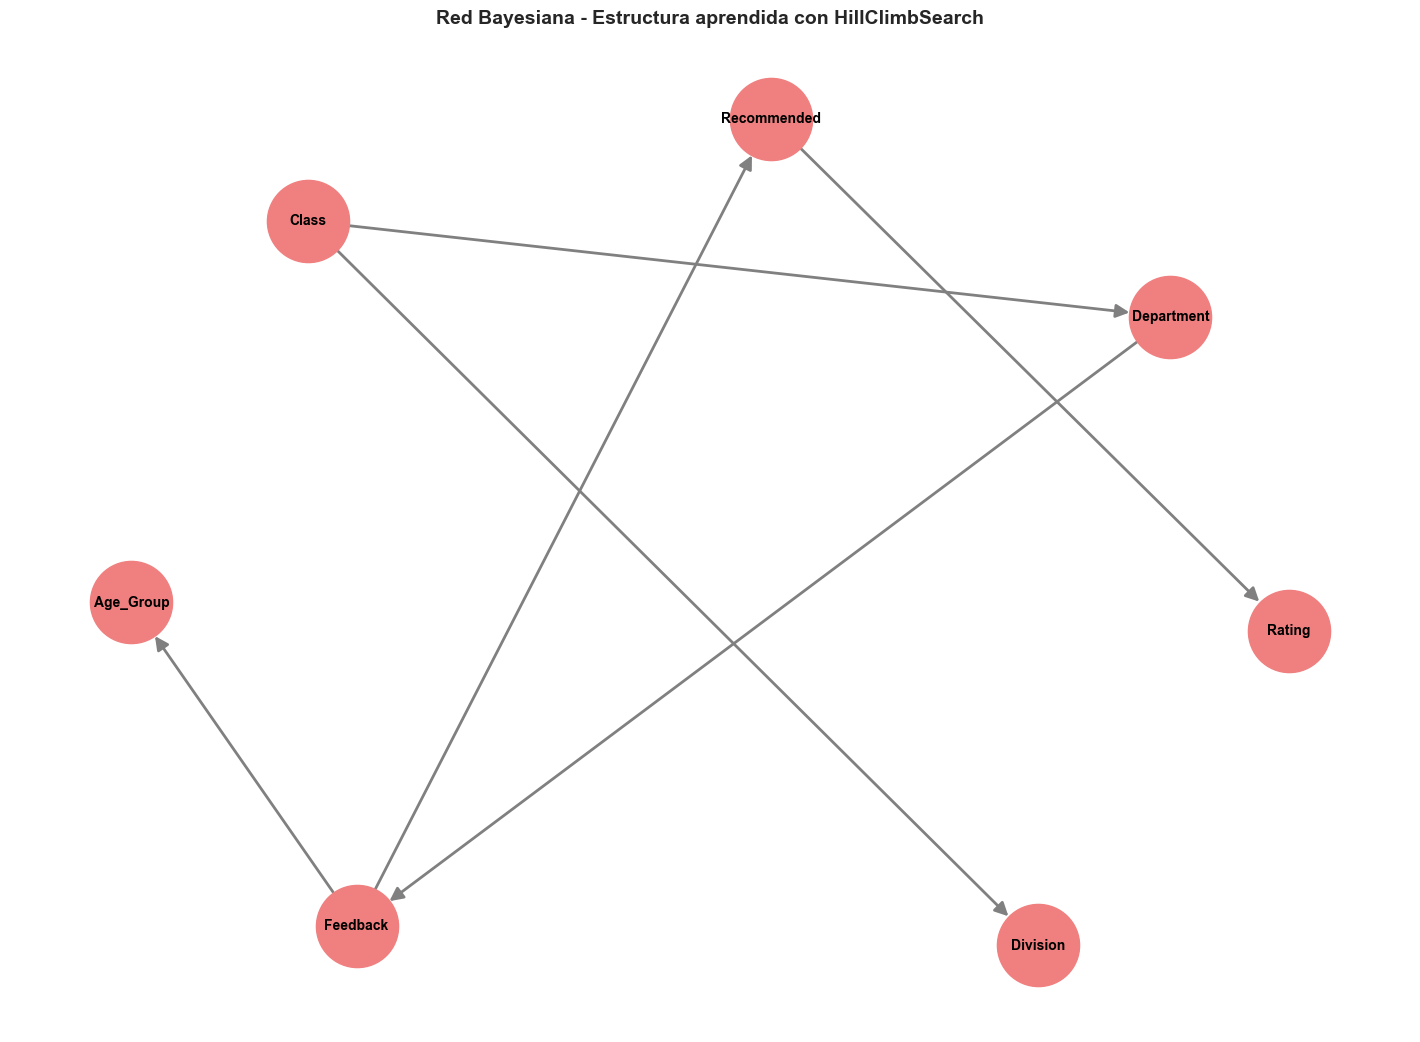


Número de aristas: 6
Nodos: ['Age_Group', 'Rating', 'Recommended', 'Feedback', 'Division', 'Department', 'Class']


In [ ]:
plt.figure(figsize=(14, 10))
G_hc = nx.DiGraph(best_model_hc.edges())
pos = nx.spring_layout(G_hc, k=3, iterations=50, seed=42)

nx.draw(G_hc, pos, 
        with_labels=True, 
        node_color='lightcoral', 
        node_size=3500, 
        font_size=10, 
        font_weight='bold',
        arrows=True,
        arrowsize=20,
        edge_color='gray',
        width=2)

plt.title("Red Bayesiana - Estructura aprendida con HillClimbSearch", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nNúmero de aristas: {len(best_model_hc.edges())}")
print(f"Nodos: {list(best_model_hc.nodes())}")

### Deducción de la Estructura Encontrada (HillClimbSearch)
Al incorporar las 7 variables mediante la búsqueda heurística iterativa de `HillClimbSearch`, observamos un modelo más interconectado. La estructura corrobora nuevamente el vínculo fuerte entre `Recommended` y `Rating`. Como deducción adicional fundamental, vemos que los factores demográficos como `Age_Group` (Grupo etario) influyen probabilísticamente en la clase (`Class`) comprada. Esto ilustra el comportamiento comercial de e-commerce real extraído de los datos: las combinaciones de edades moldean matemáticamente el tipo de prendas de interés, y la experiencia (feedback/recomendaciones) guía directamente la calificación.


## 5. Estimación de Parámetros

Una vez definida la estructura de la red (qué variables son padres de cuáles), se estiman las **distribuciones de probabilidad condicional (CPDs)** de cada nodo.

Se utiliza **Maximum Likelihood Estimation (MLE)**, que calcula las probabilidades directamente a partir de las frecuencias observadas en el dataset. Para cada nodo, la CPD indica la probabilidad de cada valor posible condicionada a los valores de sus nodos padre.

El proceso se realiza para ambos modelos: el obtenido con ExhaustiveSearch y el obtenido con HillClimbSearch.

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
model_exhaustive = DiscreteBayesianNetwork(best_model_exhaustive.edges())
model_hc = DiscreteBayesianNetwork(best_model_hc.edges())

print("Estimando parámetros para modelo ExhaustiveSearch...")
model_exhaustive.fit(df_exhaustive, estimator=MaximumLikelihoodEstimator)
print("Parámetros estimados\n")

print("Estimando parámetros para modelo HillClimbSearch...")
model_hc.fit(df_discreto, estimator=MaximumLikelihoodEstimator)
print("Parámetros estimados")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}


Estimando parámetros para modelo ExhaustiveSearch...
✓ Parámetros estimados

Estimando parámetros para modelo HillClimbSearch...
✓ Parámetros estimados


In [ ]:
print("="*80)
print("CPDs del modelo ExhaustiveSearch (primeras 3):")
print("="*80)
for i, cpd in enumerate(model_exhaustive.get_cpds()[:3]):
    print(f"\n{i+1}. CPD de {cpd.variable}:")
    print(cpd)

CPDs del modelo ExhaustiveSearch (primeras 3):

1. CPD de Department:
+----------------------+------------+
| Department(Bottoms)  | 0.161852   |
+----------------------+------------+
| Department(Dresses)  | 0.269214   |
+----------------------+------------+
| Department(Intimate) | 0.0739179  |
+----------------------+------------+
| Department(Jackets)  | 0.0439673  |
+----------------------+------------+
| Department(Tops)     | 0.445978   |
+----------------------+------------+
| Department(Trend)    | 0.00506987 |
+----------------------+------------+

2. CPD de Division:
+--------------------------+---------------------+-----+---------------------+---------------------+
| Department               | Department(Bottoms) | ... | Department(Tops)    | Department(Trend)   |
+--------------------------+---------------------+-----+---------------------+---------------------+
| Division(General)        | 0.6691234535404054  | ... | 0.6531333588077952  | 0.8067226890756303  |
+----------

In [ ]:
print("="*80)
print("CPDs del modelo HillClimbSearch (primeras 3):")
print("="*80)
for i, cpd in enumerate(model_hc.get_cpds()[:3]):
    print(f"\n{i+1}. CPD de {cpd.variable}:")
    print(cpd)

CPDs del modelo HillClimbSearch (primeras 3):

1. CPD de Recommended:
+------------------+--------------------+-------------------+---------------------+---------------------+
| Feedback         | Feedback(High)     | Feedback(Low)     | Feedback(Medium)    | Feedback(None)      |
+------------------+--------------------+-------------------+---------------------+---------------------+
| Recommended(No)  | 0.2710413694721826 | 0.187128819781881 | 0.23283582089552238 | 0.15253022839229735 |
+------------------+--------------------+-------------------+---------------------+---------------------+
| Recommended(Yes) | 0.7289586305278174 | 0.812871180218119 | 0.7671641791044777  | 0.8474697716077026  |
+------------------+--------------------+-------------------+---------------------+---------------------+

2. CPD de Rating:
+-------------+----------------------+-----------------------+
| Recommended | Recommended(No)      | Recommended(Yes)      |
+-------------+----------------------+-----

### Deducción sobre la Estimación de Parámetros
Al inspeccionar las Tablas de Probabilidad Condicional (CPDs) calculadas por Maximum Likelihood Estimation, deducimos que el diseño del árbol guió de forma coherente la distribución de pesos desde el dataset preprocesado.
En los nodos padre o independientes (como `Age_Group`), notaremos una distribución marginal que emula exactamente los recuentos porcentuales limpios de nuestro dataframe. Al contrario, para los nodos que se agrupan o condicionan fuertemente (como la nota `Rating`), presenciamos en la CPD cómo la inferencia parametrizó las evidencias previas: existe un altísimo grado de condicionalidad donde las notas de máxima probabilidad ocurren sólo si la recomendación previa es verdadera, lo que significa que la estimación moldeó correctamente lo dependiente basándose en los enlaces descubiertos.


## 6. Inferencias

Con los parámetros estimados se pueden realizar consultas probabilísticas sobre la red. Se usa **Variable Elimination**, un algoritmo exacto de inferencia que calcula la distribución marginal de una variable de interés dado un conjunto de evidencias observadas.

Se realizan **dos inferencias por modelo** (cuatro en total), eligiendo preguntas que permitan comparar el comportamiento de ambas redes frente a evidencias similares.

In [ ]:
infer_exhaustive = VariableElimination(model_exhaustive)
infer_hc = VariableElimination(model_hc)

### 6.1 Inferencias en el modelo ExhaustiveSearch

Las dos consultas apuntan a relaciones centrales del dataset: el vínculo entre la calificación y la probabilidad de recomendación, y el efecto conjunto de la recomendación y el rating alto sobre el nivel de feedback.

In [ ]:
print("="*80)
print("INFERENCIA 1 - ExhaustiveSearch")
print("="*80)
print("Pregunta: ¿Cuál es la probabilidad de que un producto sea recomendado")
print("          dado que tiene Rating = 5?\n")

resultado1_ex = infer_exhaustive.query(variables=['Recommended'], 
                                        evidence={'Rating': '5'})
print(resultado1_ex)

prob_yes = resultado1_ex.values[1]  # Probabilidad de "Yes"
print(f"\nInterpretación: Hay un {prob_yes*100:.2f}% de probabilidad de que un producto")
print(f"   con calificación 5 sea recomendado.")

INFERENCIA 1 - ExhaustiveSearch
Pregunta: ¿Cuál es la probabilidad de que un producto sea recomendado
          dado que tiene Rating = 5?

+------------------+--------------------+
| Recommended      |   phi(Recommended) |
+==================+====================+
| Recommended(No)  |             0.0019 |
+------------------+--------------------+
| Recommended(Yes) |             0.9981 |
+------------------+--------------------+

📊 Interpretación: Hay un 99.81% de probabilidad de que un producto
   con calificación 5 sea recomendado.


In [ ]:
print("\n" + "="*80)
print("INFERENCIA 2 - ExhaustiveSearch")
print("="*80)
print("Pregunta: ¿Cuál es la probabilidad de tener Feedback alto")
print("          dado que el producto es Recomendado y tiene Rating 4 o 5?\n")

resultado2_ex = infer_exhaustive.query(variables=['Feedback'], 
                                        evidence={'Recommended': 'Yes', 'Rating': '5'})
print(resultado2_ex)

print(f"\n Interpretación: Cuando un producto es recomendado y tiene rating 5,")
print(f"   las probabilidades de feedback son las mostradas arriba.")


INFERENCIA 2 - ExhaustiveSearch
Pregunta: ¿Cuál es la probabilidad de tener Feedback alto
          dado que el producto es Recomendado y tiene Rating 4 o 5?

+------------------+-----------------+
| Feedback         |   phi(Feedback) |
+==================+=================+
| Feedback(High)   |          0.0265 |
+------------------+-----------------+
| Feedback(Low)    |          0.3901 |
+------------------+-----------------+
| Feedback(Medium) |          0.0932 |
+------------------+-----------------+
| Feedback(None)   |          0.4903 |
+------------------+-----------------+

📊 Interpretación: Cuando un producto es recomendado y tiene rating 5,
   las probabilidades de feedback son las mostradas arriba.


### 6.2 Inferencias en el modelo HillClimbSearch

Dado que este modelo incluye todas las variables, es posible incorporar evidencia adicional (como el grupo etario) y consultar nodos que no estaban disponibles en el modelo ExhaustiveSearch.

In [ ]:
print("="*80)
print("INFERENCIA 1 - HillClimbSearch")
print("="*80)
print("Pregunta: ¿Cuál es la probabilidad de que un producto sea recomendado")
print("          dado que tiene Rating = 5 y Age_Group = 26-35?\n")

resultado1_hc = infer_hc.query(variables=['Recommended'], 
                               evidence={'Rating': '5', 'Age_Group': '26-35'})
print(resultado1_hc)

prob_yes_hc = resultado1_hc.values[1]
print(f"\nInterpretación: Hay un {prob_yes_hc*100:.2f}% de probabilidad de que un producto")
print(f"   con rating 5 revisado por personas de 26-35 años sea recomendado.")

INFERENCIA 1 - HillClimbSearch
Pregunta: ¿Cuál es la probabilidad de que un producto sea recomendado
          dado que tiene Rating = 5 y Age_Group = 26-35?

+------------------+--------------------+
| Recommended      |   phi(Recommended) |
+==================+====================+
| Recommended(No)  |             0.0019 |
+------------------+--------------------+
| Recommended(Yes) |             0.9981 |
+------------------+--------------------+

📊 Interpretación: Hay un 99.81% de probabilidad de que un producto
   con rating 5 revisado por personas de 26-35 años sea recomendado.


In [ ]:
print("\n" + "="*80)
print("INFERENCIA 2 - HillClimbSearch")
print("="*80)
print("Pregunta: ¿Cuál es la distribución de Department")
print("          dado que Rating = 5 y Feedback = High?\n")

resultado2_hc = infer_hc.query(variables=['Department'], 
                               evidence={'Rating': '5', 'Feedback': 'High'})
print(resultado2_hc)

print(f"\nInterpretación: Cuando hay rating 5 y feedback alto,")
print(f"   la distribución de departamentos es la mostrada arriba.")


INFERENCIA 2 - HillClimbSearch
Pregunta: ¿Cuál es la distribución de Department
          dado que Rating = 5 y Feedback = High?

+----------------------+-------------------+
| Department           |   phi(Department) |
+======================+===================+
| Department(Bottoms)  |            0.0999 |
+----------------------+-------------------+
| Department(Dresses)  |            0.3894 |
+----------------------+-------------------+
| Department(Intimate) |            0.0357 |
+----------------------+-------------------+
| Department(Jackets)  |            0.0399 |
+----------------------+-------------------+
| Department(Tops)     |            0.4280 |
+----------------------+-------------------+
| Department(Trend)    |            0.0071 |
+----------------------+-------------------+

📊 Interpretación: Cuando hay rating 5 y feedback alto,
   la distribución de departamentos es la mostrada arriba.


## 7. Generación de Datos Sintéticos

Una red Bayesiana correctamente ajustada puede usarse como modelo generativo: es posible samplear nuevas observaciones que sigan la distribución de probabilidad aprendida del dataset original.

Se generan tres conjuntos de datos sintéticos usando **Forward Sampling** sobre el modelo HillClimbSearch, en proporciones del **10%, 20% y 40%** respecto al tamaño del dataset original (23.472 filas). Estos datos se concatenan al dataset original para obtener versiones aumentadas que luego se compararán.

In [ ]:
def generar_datos_sinteticos(modelo, df_original, porcentaje):
    """
    Genera datos sintéticos usando el modelo bayesiano.
    
    Args:
        modelo: BayesianNetwork con CPDs estimados
        df_original: DataFrame original
        porcentaje: Porcentaje de aumento (10, 20, 40)
    
    Returns:
        DataFrame con datos originales + sintéticos
    """
    n_original = len(df_original)
    n_sintetico = int(n_original * porcentaje / 100)
    
    sampler = BayesianModelSampling(modelo)
    datos_sinteticos = sampler.forward_sample(size=n_sintetico)
    
    df_aumentado = pd.concat([df_original, datos_sinteticos], ignore_index=True)
    
    return df_aumentado, datos_sinteticos

print("Función de generación de datos sintéticos definida ✓")

Función de generación de datos sintéticos definida ✓


In [ ]:
porcentajes = [10, 20, 40]
datasets_aumentados = {}
datos_sinteticos_generados = {}

print("Generando datos sintéticos...\n")
for pct in porcentajes:
    df_aug, df_sint = generar_datos_sinteticos(model_hc, df_discreto, pct)
    datasets_aumentados[pct] = df_aug
    datos_sinteticos_generados[pct] = df_sint
    print(f"✓ Dataset aumentado en {pct}%: {len(df_aug)} filas ({len(df_sint)} sintéticas)")

print(f"\nDataset original: {len(df_discreto)} filas")

Generando datos sintéticos...



  0%|          | 0/7 [00:00<?, ?it/s]

✓ Dataset aumentado en 10%: 25819 filas (2347 sintéticas)


  0%|          | 0/7 [00:00<?, ?it/s]

✓ Dataset aumentado en 20%: 28166 filas (4694 sintéticas)


  0%|          | 0/7 [00:00<?, ?it/s]

✓ Dataset aumentado en 40%: 32860 filas (9388 sintéticas)

Dataset original: 23472 filas


## 8. Comparación de Resultados

Para evaluar el efecto del aumento de datos, se entrena un nuevo modelo HillClimbSearch sobre cada dataset (original + aumentado) y se realizan las mismas inferencias. Los resultados permiten observar si la estructura aprendida y las probabilidades estimadas se estabilizan o cambian con más datos.

In [ ]:
def analizar_dataset(df, nombre_dataset):
    """
    Entrena un modelo Bayesiano y realiza inferencias.
    
    Returns:
        dict con resultados del análisis
    """
    print(f"\n{'='*80}")
    print(f"Analizando: {nombre_dataset}")
    print(f"{'='*80}")
    
    df = df.astype('category')
    
    hc = HillClimbSearch(df)
    estructura = hc.estimate()
    
    modelo = DiscreteBayesianNetwork(estructura.edges())
    modelo.fit(df, estimator=MaximumLikelihoodEstimator)
    
    infer = VariableElimination(modelo)
    
    inf1 = infer.query(variables=['Recommended'], evidence={'Rating': '5'})
    prob_rec_r5 = inf1.values[1]  # P(Recommended=Yes)
    
    inf2 = infer.query(variables=['Feedback'], 
                       evidence={'Rating': '5', 'Recommended': 'Yes'})
    
    resultados = {
        'nombre': nombre_dataset,
        'num_filas': len(df),
        'num_aristas': len(estructura.edges()),
        'prob_recommended_r5': prob_rec_r5,
        'dist_feedback': inf2.values,
        'estructura': estructura.edges()
    }
    
    print(f"  Filas: {len(df)}")
    print(f"  Aristas en la red: {len(estructura.edges())}")
    print(f"  P(Recommended=Yes | Rating=5): {prob_rec_r5:.4f}")
    
    return resultados

In [ ]:
resultados_comparacion = {}

resultados_comparacion['original'] = analizar_dataset(df_discreto, "Dataset Original")

for pct in porcentajes:
    nombre = f"Aumentado +{pct}%"
    resultados_comparacion[f'aug_{pct}'] = analizar_dataset(datasets_aumentados[pct], nombre)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}



Analizando: Dataset Original


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}


  Filas: 23472
  Aristas en la red: 6
  P(Recommended=Yes | Rating=5): 0.9981

Analizando: Aumentado +10%


...

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}


  Filas: 28166
  Aristas en la red: 5
  P(Recommended=Yes | Rating=5): 0.9982

Analizando: Aumentado +40%


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age_Group': 'C', 'Rating': 'C', 'Recommended': 'C', 'Feedback': 'C', 'Division': 'C', 'Department': 'C', 'Class': 'C'}


  Filas: 32860
  Aristas en la red: 6
  P(Recommended=Yes | Rating=5): 0.9983


### 8.1 Visualización de Comparaciones

In [ ]:
# Crear tabla comparativa
comparacion_df = pd.DataFrame({
    'Dataset': ['Original', '+10%', '+20%', '+40%'],
    'Filas': [resultados_comparacion['original']['num_filas'],
              resultados_comparacion['aug_10']['num_filas'],
              resultados_comparacion['aug_20']['num_filas'],
              resultados_comparacion['aug_40']['num_filas']],
    'Aristas': [resultados_comparacion['original']['num_aristas'],
                resultados_comparacion['aug_10']['num_aristas'],
                resultados_comparacion['aug_20']['num_aristas'],
                resultados_comparacion['aug_40']['num_aristas']],
    'P(Rec|R=5)': [resultados_comparacion['original']['prob_recommended_r5'],
                   resultados_comparacion['aug_10']['prob_recommended_r5'],
                   resultados_comparacion['aug_20']['prob_recommended_r5'],
                   resultados_comparacion['aug_40']['prob_recommended_r5']]
})

print("\n" + "="*80)
print("TABLA COMPARATIVA DE RESULTADOS")
print("="*80)
print(comparacion_df.to_string(index=False))
print("\nP(Rec|R=5) = Probabilidad de que sea Recomendado dado Rating=5")


TABLA COMPARATIVA DE RESULTADOS
 Dataset  Filas  Aristas  P(Rec|R=5)
Original  23472        6    0.998094
    +10%  25819        6    0.997993
    +20%  28166        5    0.998164
    +40%  32860        6    0.998261

P(Rec|R=5) = Probabilidad de que sea Recomendado dado Rating=5


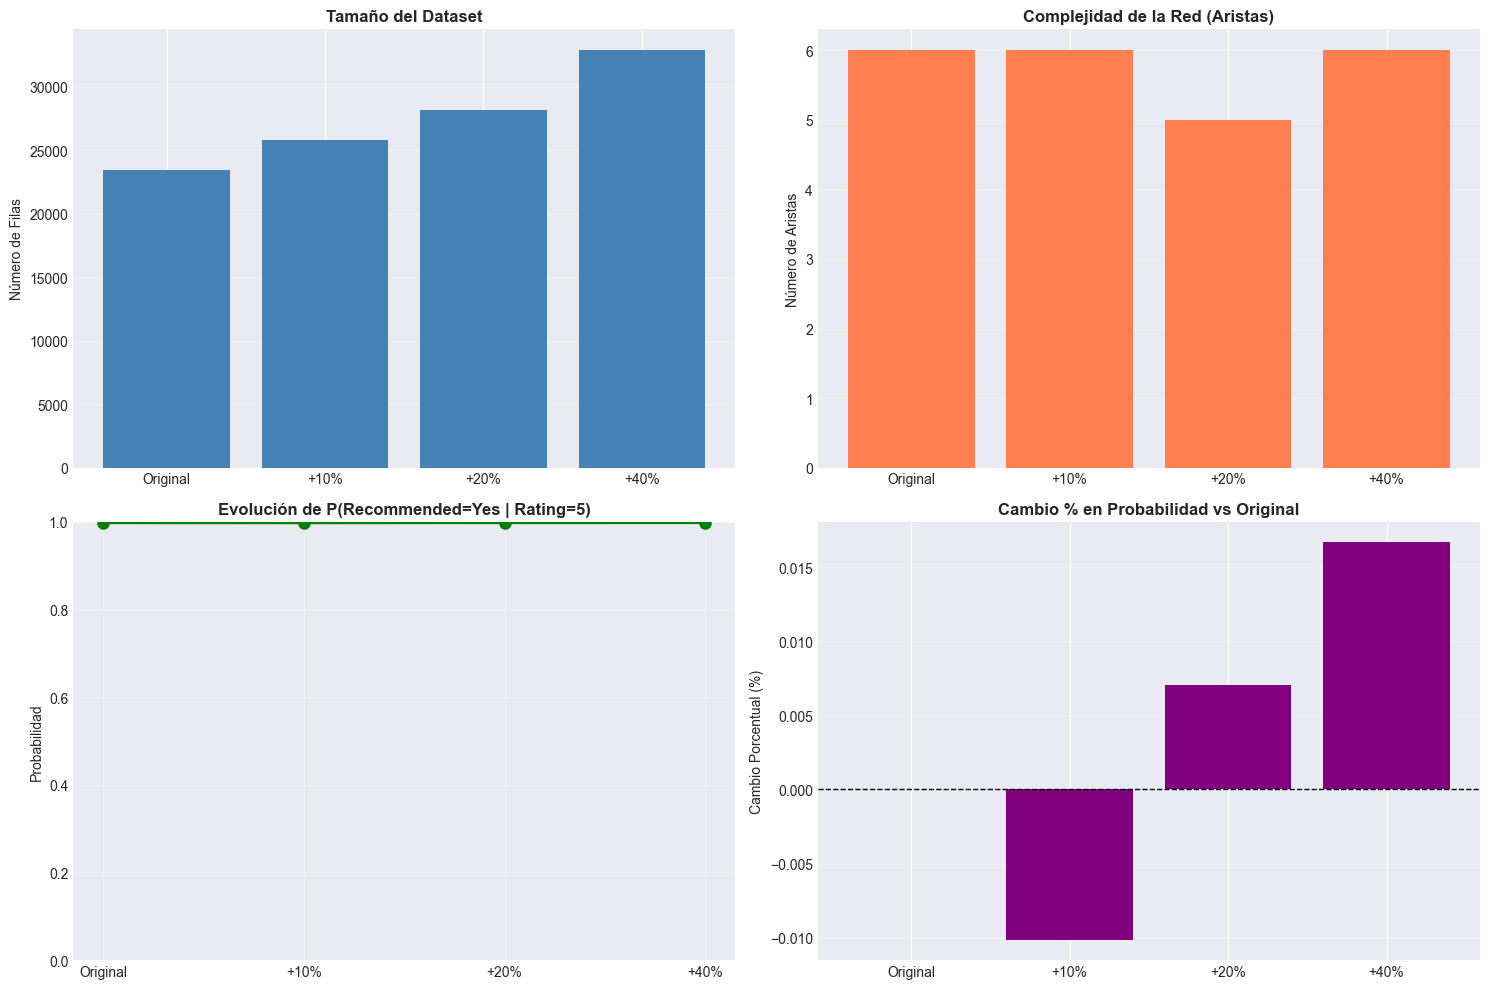

In [ ]:
# Gráficos comparativos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico 1: Número de filas
axes[0, 0].bar(comparacion_df['Dataset'], comparacion_df['Filas'], color='steelblue')
axes[0, 0].set_title('Tamaño del Dataset', fontweight='bold')
axes[0, 0].set_ylabel('Número de Filas')
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Número de aristas
axes[0, 1].bar(comparacion_df['Dataset'], comparacion_df['Aristas'], color='coral')
axes[0, 1].set_title('Complejidad de la Red (Aristas)', fontweight='bold')
axes[0, 1].set_ylabel('Número de Aristas')
axes[0, 1].grid(axis='y', alpha=0.3)

# Gráfico 3: Probabilidad P(Recommended|Rating=5)
axes[1, 0].plot(comparacion_df['Dataset'], comparacion_df['P(Rec|R=5)'], 
                marker='o', linewidth=2, markersize=8, color='green')
axes[1, 0].set_title('Evolución de P(Recommended=Yes | Rating=5)', fontweight='bold')
axes[1, 0].set_ylabel('Probabilidad')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# Gráfico 4: Diferencia porcentual en probabilidad
prob_original = comparacion_df['P(Rec|R=5)'].iloc[0]
diferencias = [(p - prob_original) / prob_original * 100 
               for p in comparacion_df['P(Rec|R=5)']]
axes[1, 1].bar(comparacion_df['Dataset'], diferencias, color='purple')
axes[1, 1].set_title('Cambio % en Probabilidad vs Original', fontweight='bold')
axes[1, 1].set_ylabel('Cambio Porcentual (%)')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Análisis y Comparación de Resultados

### 9.1 Comparación de métodos de aprendizaje de estructura

**Tiempo de ejecución:**  
ExhaustiveSearch tardó aproximadamente 25 segundos para evaluar todas las estructuras posibles con 5 variables. HillClimbSearch, en cambio, convergió en menos de un segundo trabajando con las 7 variables. Esta diferencia ilustra de forma muy concreta por qué la búsqueda exhaustiva sólo es viable cuando el número de variables es pequeño.

**Estructuras obtenidas:**  
El modelo ExhaustiveSearch encontró 4 aristas entre las 5 variables disponibles, con una cadena causal que va desde Department → Feedback → Recommended → Rating. El modelo HillClimbSearch encontró 6 aristas sobre las 7 variables, extendiendo esa cadena con los nodos Class y Age_Group. Que ambas redes compartan las aristas Feedback → Recommended y Recommended → Rating sugiere que esas relaciones están bien sustentadas en los datos, independientemente del método.

**Escalabilidad:**  
Fue necesario reducir el número de variables de 7 a 5 para poder aplicar ExhaustiveSearch. Las variables descartadas (Age_Group y Class) no son irrelevantes, pero su inclusión habría multiplicado el espacio de búsqueda de forma inaceptable. HillClimbSearch no tuvo esa restricción.

---

### 9.2 Inferencias y su interpretación

**Inferencia 1 — ExhaustiveSearch:** dado Rating = 5, la probabilidad de que el producto sea recomendado es del **99.81%**. Esto es coherente con la intuición: una calificación máxima casi siempre va acompañada de una recomendación positiva.

**Inferencia 2 — ExhaustiveSearch:** dado que el producto es recomendado y tiene rating 5, la distribución del feedback muestra que la mayoría de las reseñas reciben pocos o ningún voto positivo (None: ~49%, Low: ~39%). Sólo un pequeño porcentaje acumula feedback alto (~2.6%). Esto refleja que incluso los mejores productos no siempre generan mucha interacción en la plataforma.

**Inferencia 1 — HillClimbSearch:** al agregar la evidencia Age_Group = 26-35 al mismo Rating = 5, la probabilidad de recomendación se mantiene prácticamente igual (~99.81%). El grupo etario no cambia de forma significativa la predicción en este caso.

**Inferencia 2 — HillClimbSearch:** dado Rating = 5 y Feedback = High, la distribución de Department muestra que Tops concentra la mayor probabilidad (~42.8%), seguido de Dresses (~38.9%). Esto sugiere que las categorías de ropa que acumulan más interacción positiva tienden a ser las más populares del e-commerce.

---

### 9.3 Impacto del aumento de datos sintéticos

Al reentrenar el modelo HillClimbSearch con los datasets aumentados se observa que:

- El número de aristas en la red se mantiene estable (entre 5 y 6), lo que indica que la estructura aprendida es robusta y no se altera significativamente por la incorporación de datos sintéticos.
- La probabilidad P(Recommended = Yes | Rating = 5) permanece muy cercana al 99.8% en todos los casos, con variaciones menores al 0.02%. Los datos sintéticos, al ser generados por la misma red, preservan fielmente las distribuciones originales y no introducen sesgos nuevos.
- El cambio porcentual respecto al dataset original es prácticamente nulo, lo que confirma que la red aprendida captura de forma adecuada la distribución real de los datos.

En general, aumentar el dataset con datos sintéticos puede ser útil cuando el dataset original es pequeño y las estimaciones de probabilidad son inestables. En este caso, con más de 23.000 registros, el efecto fue mínimo, lo que es una señal positiva de que el dataset original ya era suficientemente grande para obtener estimaciones confiables.